# Calibrating a local optical potential to a real measurement

This is the production path, end to end: we take a measurement as EXFOR reports
it, convert it into the library's units, decide on an error model, calibrate a
local optical potential against it with nested sampling, and predict on a grid
the experiment never measured.

The data are real, and that matters for everything that follows.  They are
[EXFOR entry O1199](https://www-nds.iaea.org/exfor/), subentry O1199007:
$p + {}^{40}\mathrm{Ca}$ elastic scattering at 35 MeV, reported as a ratio to
the Rutherford cross section, 59 angles from 6 to 163 degrees, with statistical
errors of about 2.3 % — and **no systematic uncertainty quoted at all**.  That
last omission is not unusual, and it shapes the error model we end up with.

Recipes: 4, 12, 14, 15, 16, 21, 26

In [1]:
from dataclasses import dataclass

import corner
import dill
import dynesty
import emcee
import jitr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotstyle
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere,
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from scipy import stats

import rxmc as rx
from rxmc import terms as T

plotstyle.use()

## The measurement

The file was pulled from the EXFOR database once and committed next to this
notebook, so that the notebook runs anywhere:

```python
import exfor_tools as et
from exfor_tools import curate

reaction = et.reaction.Reaction(target=(40, 20), projectile=(1, 1), process="EL")
entries, failed = curate.query_for_entries(reaction=reaction, quantity="dXS/dRuth")
```

`process="EL"` is the part worth remembering: EXFOR spells elastic scattering
`(P,EL)`, and asking for a product tuple instead returns nothing at all,
silently.

`exfor_tools` hands back a `Distribution` object.  Rather than depend on the
database here, we stand in for it with a small dataclass carrying the same
fields — which is all `rx.from_measurement` asks for.

In [2]:
@dataclass
class Measurement:
    """The fields rx.from_measurement reads off an exfor_tools Distribution."""

    x: np.ndarray  # angles, degrees
    y: np.ndarray
    statistical_err: np.ndarray
    Einc: float
    quantity: str
    y_units: str
    x_units: str
    systematic_norm_err: float
    systematic_offset_err: float
    subentry: str


df = pd.read_csv("data/p40ca_elastic_35mev.csv")
measurement = Measurement(
    x=df["angle_cm_deg"].to_numpy(),
    y=df["ratio_to_rutherford"].to_numpy(),
    statistical_err=df["stat_err"].to_numpy(),
    Einc=35.0,
    quantity="dXS/dRuth",
    y_units="no-dim",
    x_units="CM-degrees",
    systematic_norm_err=0.0,  # this entry quotes none
    systematic_offset_err=0.0,
    subentry="O1199007",
)
print(
    f"{measurement.x.size} angles, {measurement.x.min():.1f} to {measurement.x.max():.1f} deg"
)
print(
    f"relative statistical error: {np.mean(measurement.statistical_err / measurement.y):.1%}"
)

59 angles, 6.3 to 163.3 deg
relative statistical error: 2.3%


## `from_measurement`: the unit contract

Angles become radians, cross sections become b/sr, every *dimensionful* error is
converted with the data, and a *fractional* normalisation error passes through
untouched.  The kinematics a reaction model needs land in `meta`.

Two things this measurement exercises.  It is in the **CM frame** — a LAB-frame
entry is refused rather than silently mis-analysed.  And because it is a ratio
to Rutherford, asking for `dXS/dA` converts it through the Rutherford cross
section, which is a closed form of the kinematics (recipe 14).

In [3]:
reaction = jitr.reactions.ElasticReaction(target=(40, 20), projectile=(1, 1))
data = rx.from_measurement(measurement, reaction=reaction)
absolute = rx.from_measurement(measurement, reaction=reaction, quantity="dXS/dA")
print(data)
print(f"ratio:    y[:3] = {data.y[:3].round(3)} (dimensionless)")
print(f"absolute: y[:3] = {absolute.y[:3].round(4)} b/sr")
print("meta:", {k: v for k, v in data.meta.items() if k != "reaction"})

Dataset('O1199007', n=59)
ratio:    y[:3] = [1.41 1.93 2.05] (dimensionless)
absolute: y[:3] = [71.2624 18.1398  7.6554] b/sr
meta: {'quantity': 'dXS/dRuth', 'Elab': 35.0, 'subentry': 'O1199007', 'k': 1.277431188612647, 'eta': 0.5484365614354219}


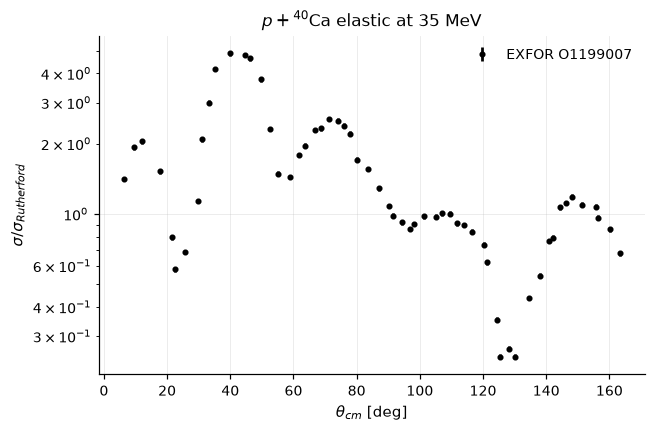

In [4]:
fig, ax = plt.subplots()
ax.errorbar(
    np.rad2deg(data.x),
    data.y,
    data.y_err,
    fmt="o",
    ms=3,
    color="k",
    label=f"EXFOR {measurement.subentry}",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Rutherford}$",
    yscale="log",
    title=r"$p + {}^{40}$Ca elastic at 35 MeV",
)
ax.legend()
plt.show()

## The potential

A Woods-Saxon with volume and surface absorption, a fixed spin-orbit term, and —
because the projectile is charged — a Coulomb term from a uniformly charged
sphere.  `ElasticXS` is a `Model` whose `bind` compiles a
[jitr](https://github.com/beykyle/jitr) solver for the dataset's kinematics,
which it reads from `meta`.

The model's quantity and the dataset's must agree: comparing a ratio-to-Rutherford
measurement against a `dXS/dA` model is refused at construction, not discovered
after a fit.

In [5]:
A13 = 40 ** (1 / 3)
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def central(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) - 1j * Wd * (
        -4 * ad
    ) * woods_saxon_prime_safe(r, Rd, ad)


def spin_orbit(r, Vso, Rso, aso):
    return Vso * mso**2 * thomas_safe(r, Rso, aso)


def coulomb(r):
    return coulomb_charged_sphere(
        r, reaction.target.Z * reaction.projectile.Z, 1.3 * A13
    )


so_args = (5.5, 1.0 * A13, 0.6)  # held fixed: 59 angles at one energy cannot fit it

In [6]:
names = ["Vv", "Wv", "Rv", "av", "Wd", "Rd", "ad"]
latex = ["V_v", "W_v", "R_v", "a_v", "W_d", "R_d", "a_d"]
start = np.array([45.0, 3.0, 1.18 * A13, 0.68, 6.0, 1.28 * A13, 0.55])
prior_sd = np.array([8.0, 3.0, 0.25, 0.15, 5.0, 0.25, 0.15])
lower = np.array([0.0, 0.0, 1.0, 0.2, 0.0, 1.0, 0.2])
params = [
    rx.Parameter(n, prior=stats.norm(mu, sd), bounds=(lo, np.inf), latex=lt)
    for n, mu, sd, lo, lt in zip(names, start, prior_sd, lower, latex)
]
omp = rx.reactions.ElasticXS(
    "dXS/dRuth",
    central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    params,
    coulomb=coulomb,
    lmax=30,
)
comp = rx.Comparison(data, omp)
print(
    "chi2 per point at the starting potential:",
    round(rx.Problem([rx.Constraint([comp])]).chi2(start) / data.n, 1),
)

chi2 per point at the starting potential: 987.0


## An error model for data that quote no systematics

That $\chi^2$ per point is the whole problem in one number.  The statistical
errors are 2.3 %, and a seven-parameter local potential simply cannot describe
real elastic scattering to 2.3 % across 59 angles.  If we fit with the quoted
errors alone, we are telling the sampler that every remaining disagreement is a
statistical fluctuation, and it will believe us.

The measurement quotes no systematic uncertainty, so there is nothing to fold in
(`comp.reported_terms()` would return an empty list).  We have two honest
options, and we will try both against the bare fit:

- **infer a normalisation** (recipe 4): one rank-one mode built from the
  prediction, with its magnitude $\eta$ sampled.  This says the scale of the
  measurement is uncertain even though nobody quoted a number for it;
- **infer a model error** (recipe 26): a diagonal term that grows with the
  prediction, $\delta$ sampled.  This says our *model*, not the measurement, is
  the thing that is wrong at the percent level.

In [7]:
log_eta = rx.Parameter(
    "log_eta", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\eta"
)
log_delta = rx.Parameter(
    "log_delta", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\delta"
)
norm_term = T.normalization(parameter=log_eta)
model_error_term = T.model_error(log_delta, averaging=True)
problems = {
    "quoted errors only": rx.Problem([rx.Constraint([comp])]),
    "inferred normalisation": rx.Problem([rx.Constraint([comp], terms=[norm_term])]),
    "inferred model error": rx.Problem(
        [rx.Constraint([comp], terms=[model_error_term])]
    ),
}
# the inferred terms of each error model: functions of the prediction, so they
# are defined on any angular grid, unlike the quoted per-point statistical errors
inferred_terms = {
    "quoted errors only": [],
    "inferred normalisation": [norm_term],
    "inferred model error": [model_error_term],
}
for name, p in problems.items():
    print(f"{name:24s} {p.ndim} columns: {p.names}")

quoted errors only       7 columns: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad']
inferred normalisation   8 columns: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad', 'log_eta']
inferred model error     8 columns: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad', 'log_delta']


## Calibrating with nested sampling (recipe 16)

Optical-model posteriors are correlated and often multimodal, where an
affine-invariant ensemble mixes poorly;
[dynesty](https://dynesty.readthedocs.io/) copes with them and returns the
evidence as a by-product.  It needs two callables — `log_likelihood` and
`prior_transform` — and the transform maps the unit cube through every
parameter's truncated prior, which the problem assembles for us.

In [8]:
def nested(problem, seed, nlive=150, dlogz=0.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    res = sampler.results
    print(
        f"log Z = {res.logz[-1]:9.2f} +/- {res.logzerr[-1]:.2f}, "
        f"{int(np.sum(res.ncall)):7d} calls, efficiency {res.eff:.1f} %"
    )
    return res.samples_equal(rstate=np.random.default_rng(seed))


samples = {}
for i, (name, p) in enumerate(problems.items()):
    print(f"{name:24s}", end=" ")
    samples[name] = nested(p, seed=1 + i)

quoted errors only       

log Z =  -3478.97 +/- 0.69,  126410 calls, efficiency 4.1 %
inferred normalisation   

log Z =  -3360.89 +/- 0.71,  131731 calls, efficiency 3.9 %
inferred model error     

log Z =    -38.66 +/- 0.54,   77464 calls, efficiency 4.2 %


In [9]:
for name, p in problems.items():
    s = samples[name]
    theta = np.median(s, axis=0)
    extra = ""
    if "normalisation" in name:
        extra = f"   eta = {np.exp(s[:, p.columns(log_eta)]).mean():.1%}"
    if "model error" in name:
        extra = f"   delta = {np.exp(s[:, p.columns(log_delta)]).mean():.1%}"
    print(
        f"{name:24s} chi2/N = {p.chi2(theta) / data.n:7.1f}"
        f"   Vv = {s[:, p.columns(params[0])].mean():5.1f}"
        f" +/- {s[:, p.columns(params[0])].std():4.1f}{extra}"
    )

quoted errors only       chi2/N =   122.1   Vv =  45.5 +/-  0.1
inferred normalisation   chi2/N =   118.0   Vv =  42.6 +/-  0.2   eta = 19.8%
inferred model error     chi2/N =     0.9   Vv =  44.6 +/-  2.3   delta = 30.0%


### What the three error models made of it

The evidence is not close: $-3479$ for the quoted errors, $-3361$ with an
inferred normalisation, $-38.7$ with an inferred model error.  The measurement's
2.3 % statistical errors cannot explain the disagreement, and the fit knows it.

The interesting comparison is the middle one.  Letting the *scale* of the
measurement float — by 19.8 %, which is a lot — buys almost nothing: the
evidence moves by about 120 out of 3400, and $\chi^2/N$ stays at 118.  A
normalisation multiplies every angle by the same number, and our problem is not
that the data sit at the wrong level.  It is that the shape is wrong, angle by
angle, and no single factor repairs a shape.

The inferred model error, which grows with the prediction at every angle, takes
$\chi^2/N$ from 122 to 0.9 with $\delta = 30\,\%$.  That is the honest summary
of this fit: a seven-parameter local potential describes this measurement to
about 30 %, not to the 2.3 % the counting statistics suggest.  The uncertainty
on $V_v$ moves accordingly, from $\pm 0.1$ MeV — precise and meaningless — to
$\pm 2.3$ MeV.

### Predicting between and beyond the measured angles

A prediction on a finer angular grid can carry an error model only where that
error model has a value.  The quoted 2.3 % statistical errors are one number per
measured angle, so `grid_draws` cannot put them anywhere else, and we leave them
out.  The inferred terms are different: the normalisation mode is $\eta\,y_m$
and the model error is $\delta\,y_m$ at any angle, so we pass them with
`terms=` and each band includes the uncertainty its error model inferred.  (A
normalisation drawn on the grid reads as "a future measurement by this
experiment", sharing its unknown scale.)  For the quoted-errors fit that leaves
the model alone, which is exactly why its band is so implausibly thin.

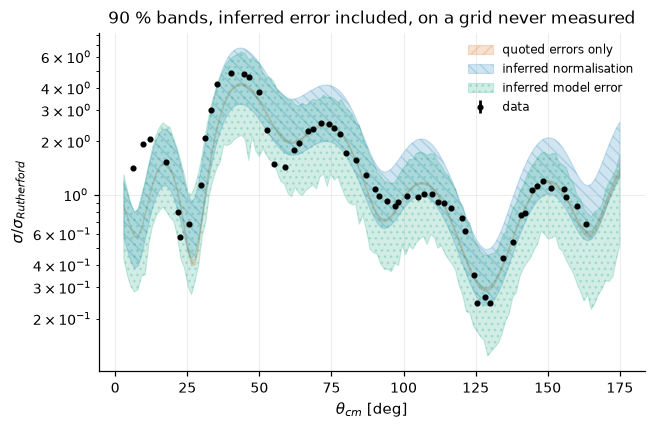

In [10]:
x_fine = np.deg2rad(np.linspace(3.0, 175.0, 140))
on_fine = omp.bind(x_fine, data.meta)
fig, ax = plt.subplots()
for (name, p), colour, hatch in zip(
    problems.items(),
    [plotstyle.COLOURS[i] for i in (1, 0, 2)],
    plotstyle.HATCHES,
):
    lo, hi = rx.predictive.grid_draws(
        p, on_fine, x_fine, samples[name][::20], terms=inferred_terms[name],
        n_rep=2, levels=(5, 95), rng=4,
    )  # fmt: skip
    plotstyle.band(
        ax, np.rad2deg(x_fine), lo, hi, color=colour, hatch=hatch, label=name
    )
ax.errorbar(
    np.rad2deg(data.x), data.y, data.y_err, fmt="o", ms=3, color="k", label="data"
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Rutherford}$",
    yscale="log",
    title="90 % bands, inferred error included, on a grid never measured",
)
ax.legend(fontsize=8)
plt.show()

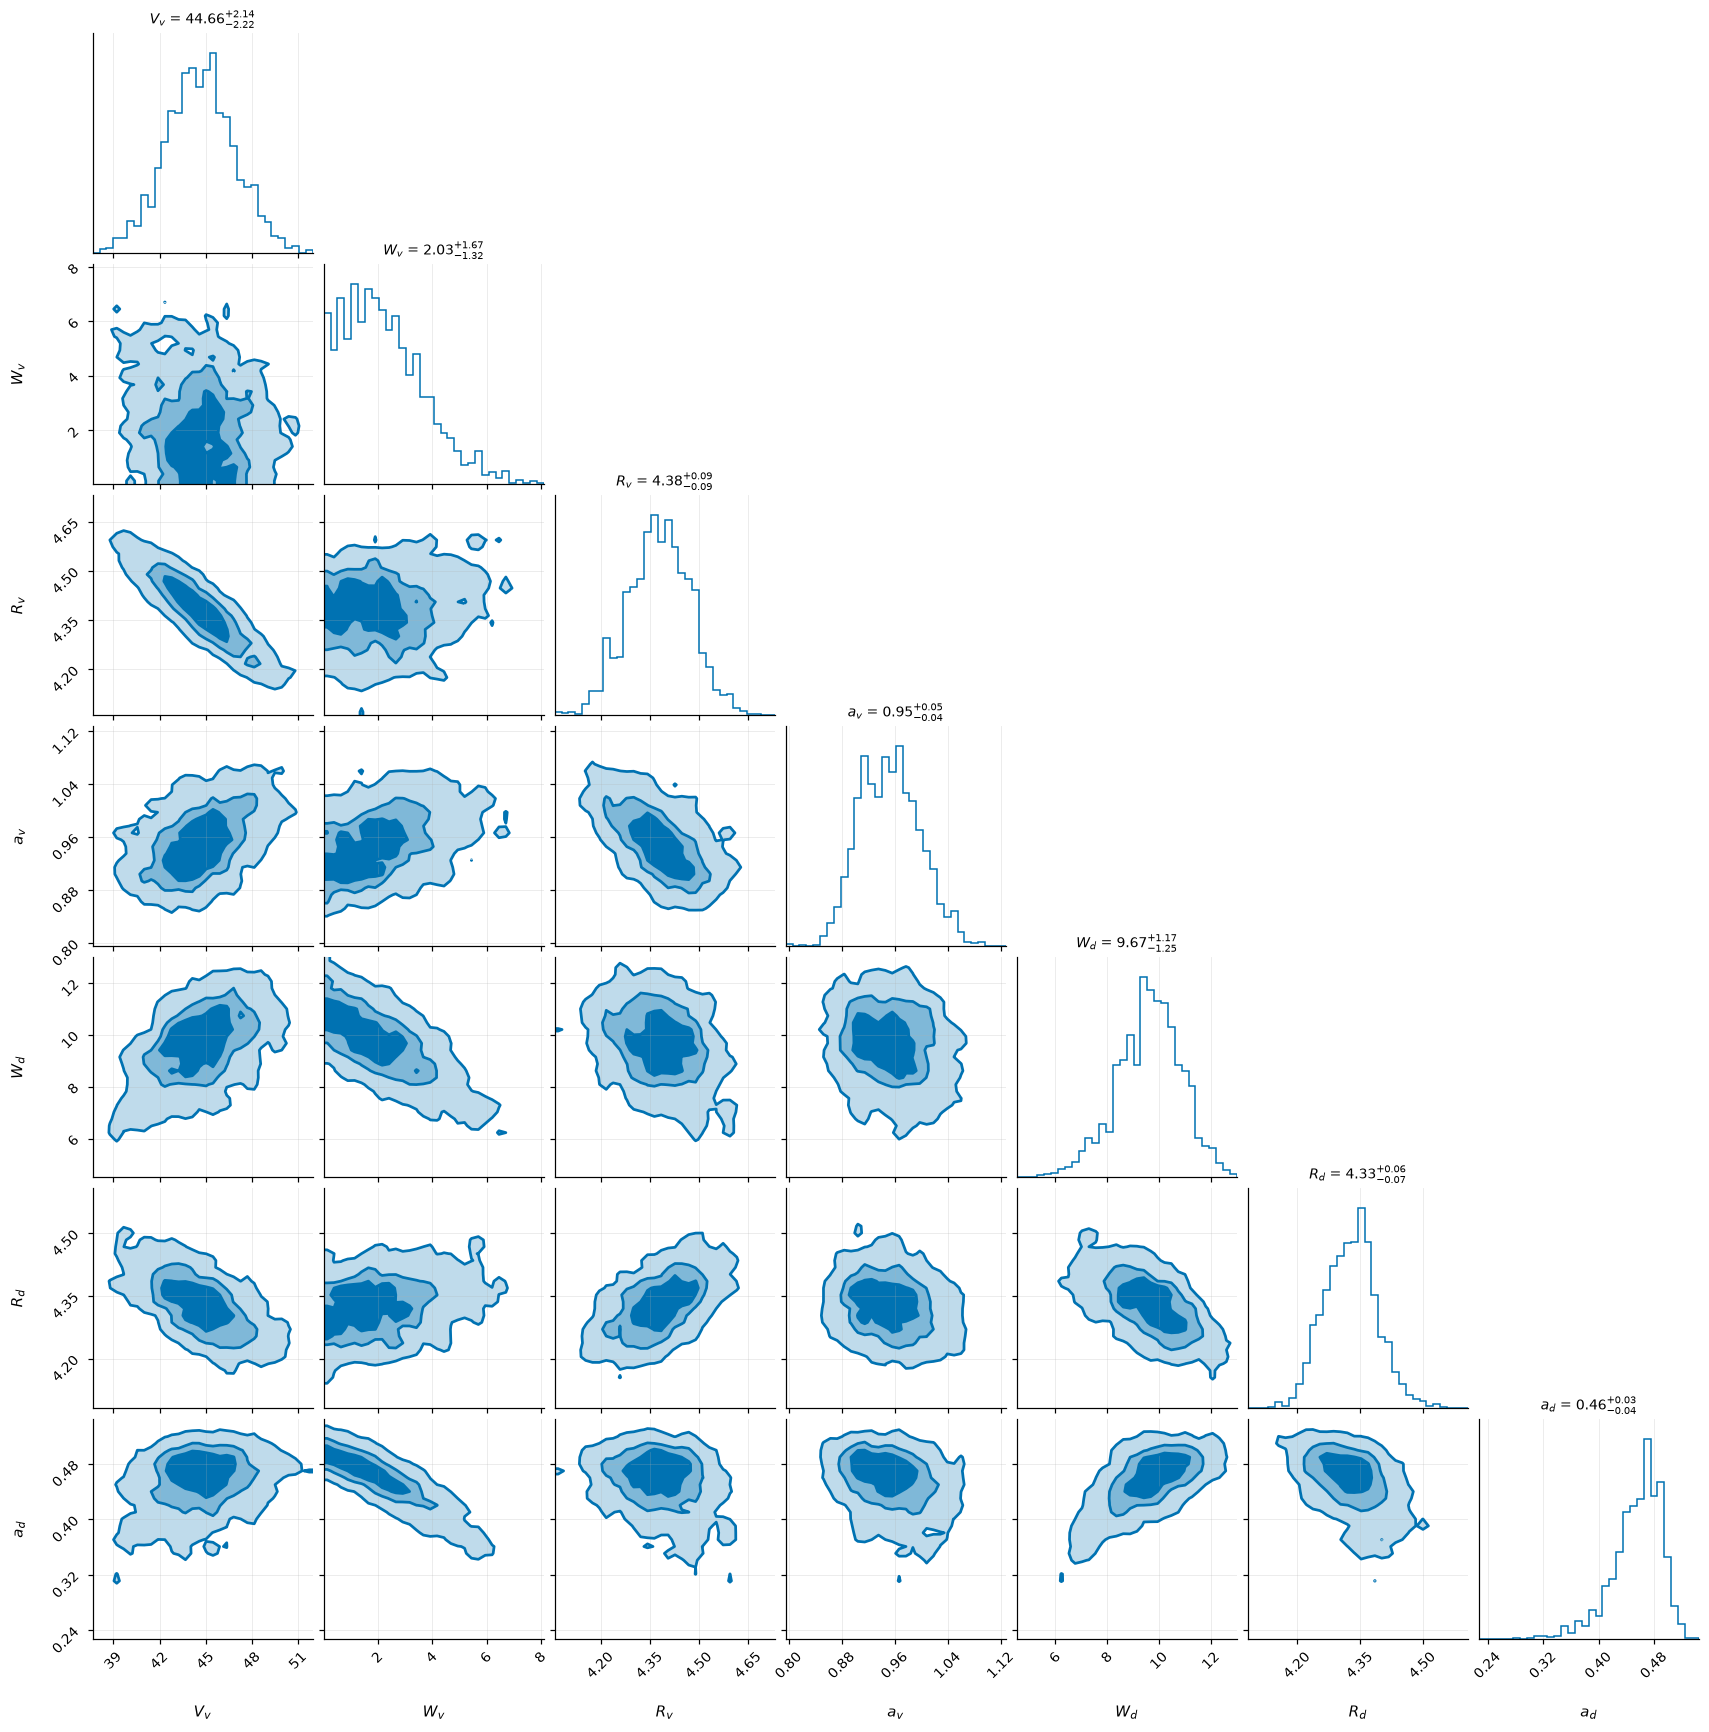

In [11]:
best = "inferred model error"
p_best = problems[best]
fig = corner.corner(
    samples[best][:, p_best.columns(omp.params)],
    labels=[f"${lt}$" for lt in latex],
    **plotstyle.corner_kwargs(title_fmt=".2f"),
)
plt.show()

## The guardrail: a covariance that cannot be factored (recipe 21)

If a subentry reports no statistical error either — it happens — the covariance
of those points is singular, and there is nothing sensible to do with it.  The
library says so when the problem is built, naming the dataset, rather than
failing somewhere inside the sampler an hour later.

In [12]:
no_errors = rx.Dataset(
    data.x[:6],
    data.y[:6],
    np.zeros(6),
    label="a subentry with no errors",
    meta=data.meta,
)
try:
    rx.Problem([rx.Constraint([rx.Comparison(no_errors, omp)])])
except ValueError as err:
    print(err)

the constraint's covariance is singular on its active points; the diagonal is zero on rows of ['a subentry with no errors']: those comparisons have zero statistical error and no diagonal term covers their points (a block covered only by correlated modes is singular here even when the full covariance is not).  Remedies: comparison.reported_terms(), a noise term, a fixed Term covering those points, or statistical=False with an explicit covariance.


## Other drivers (recipe 16)

The same problem runs under emcee from `sample_prior` and `log_posterior`, and
it pickles with `dill` for a driver in another process.  The short run below
only demonstrates the contract; on an optical-model posterior expect to need far
more emcee steps than dynesty needs live points.

In [13]:
sampler = emcee.EnsembleSampler(16, p_best.ndim, p_best.log_posterior)
sampler.random_state = np.random.RandomState(2).get_state()
sampler.run_mcmc(p_best.sample_prior(16, rng=2), 200, progress=False)
print(
    f"emcee: {sampler.get_chain(flat=True).shape[0]} rows, "
    f"mean acceptance {sampler.acceptance_fraction.mean():.2f}"
)
restored = dill.loads(dill.dumps(p_best))
theta_best = np.median(samples[best], axis=0)
print(
    f"dill round trip: ndim {restored.ndim}, "
    f"log_posterior = {restored.log_posterior(theta_best):.3f} "
    f"vs {p_best.log_posterior(theta_best):.3f}"
)

emcee: 3200 rows, mean acceptance 0.25
dill round trip: ndim 8, log_posterior = -28.425 vs -28.425


## Tempering the likelihood (recipe 12)

With many points a posterior can collapse tighter than the model deserves.
`Constraint(weight=w)` multiplies that constraint's log-likelihood by $w$ and
changes nothing else; KDUQ's "democratic" scaling is the case
$w = n_\mathrm{parameters} / n_\mathrm{points}$.

We show it on a 200-point line, where the truth is known exactly, so we can ask
the question that matters: does tempering improve anything we care about?

In [14]:
rng = np.random.default_rng(11)
x200 = np.linspace(0.0, 1.0, 200)
m_true, b_true = 2.0, 4.0
y200 = (m_true * x200 + b_true) * (1.0 + rng.normal(0.0, 0.05, x200.size))
d200 = rx.Dataset(x200, y200, 0.05 * y200, label="N = 200")
m_ = rx.Parameter("m", prior=stats.norm(1.0, 0.5), latex="m")
b_ = rx.Parameter("b", prior=stats.norm(4.0, 0.5), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m_, b_])
comp200 = rx.Comparison(d200, line)
p_full = rx.Problem([rx.Constraint([comp200])])
p_temp = rx.Problem([rx.Constraint([comp200], weight=2 / 200)])


def fit(problem, seed, n_walkers=24, n_steps=2000):
    s = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    s.random_state = np.random.RandomState(seed).get_state()
    s.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return s.get_chain(discard=n_steps // 3, thin=5, flat=True)


s_full, s_temp = fit(p_full, 3), fit(p_temp, 4)
for name, s in (("untempered", s_full), ("tempered", s_temp)):
    pull_m = (s[:, 0].mean() - m_true) / s[:, 0].std()
    pull_b = (s[:, 1].mean() - b_true) / s[:, 1].std()
    print(
        f"{name:11s} m = {s[:, 0].mean():.4f} +/- {s[:, 0].std():.4f} (pull {pull_m:+.1f})"
        f"   b = {s[:, 1].mean():.4f} +/- {s[:, 1].std():.4f} (pull {pull_b:+.1f})"
    )

untempered  m = 1.9792 +/- 0.0601 (pull -0.3)   b = 3.9927 +/- 0.0305 (pull -0.2)
tempered    m = 1.4720 +/- 0.3661 (pull -1.4)   b = 4.1842 +/- 0.2158 (pull +0.9)


### Does tempering help here?

The untempered fit covers the truth comfortably: $m = 1.979 \pm 0.060$ against
2.0, and $b = 3.993 \pm 0.031$ against 4.0, both within a third of a standard
deviation.  That is worth saying plainly, because a posterior this tight *looks*
alarming beside a wide prior, and it is easy to read the corner plot as a
failure to cover.  It is not: 200 points at 5 % each really do pin a straight
line that well.

Tempering by $k/N$ widens the posterior roughly sixfold, and here it makes the
answer slightly *worse* rather than better ($m = 1.47 \pm 0.37$, 1.4 sigma low).
The coverage curve below is the check that actually matters, and the untempered
predictive already follows the diagonal: the prediction of the *data* carries
the noise even when the parameter posterior is narrow.  Temper when the
predictions are overconfident, not when the parameters merely look precise.

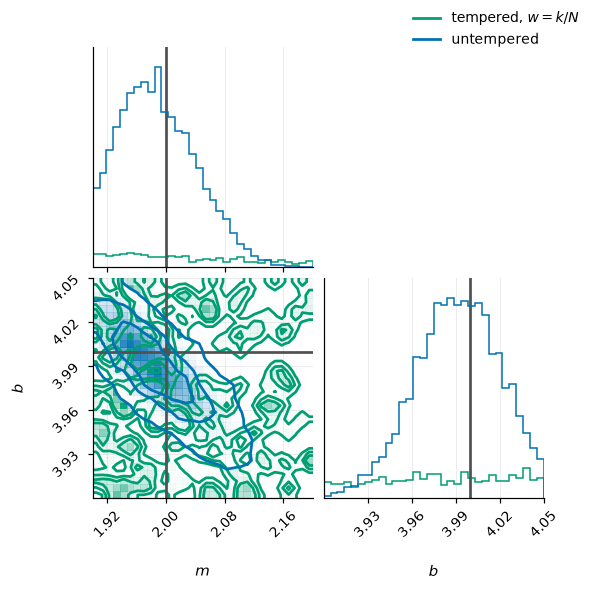

In [15]:
# the posterior is tiny compared with the prior, so the corner is drawn on the
# posterior's own scale; on the prior's scale both fits are a single dot
span = [(1.90, 2.20), (3.90, 4.05)]
fig = corner.corner(
    s_temp,
    labels=["$m$", "$b$"],
    truths=[m_true, b_true],
    range=span,
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[2], fill_contours=False, show_titles=False
    ),
)
corner.corner(
    s_full,
    fig=fig,
    range=span,
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[0], fill_contours=False, show_titles=False
    ),
)
fig.legend(
    handles=[
        plt.Line2D([], [], color=plotstyle.COLOURS[2], label="tempered, $w = k/N$"),
        plt.Line2D([], [], color=plotstyle.COLOURS[0], label="untempered"),
    ],
    loc="upper right",
)
plt.show()

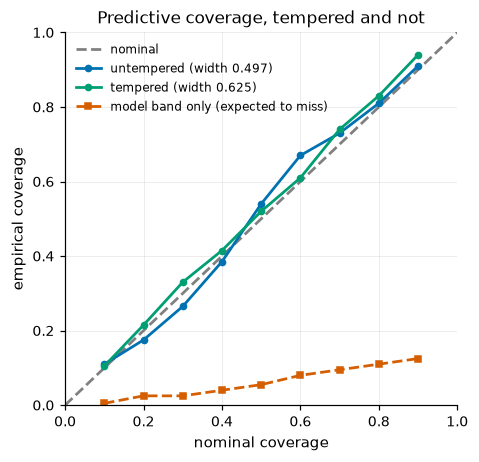

In [16]:
levels = np.linspace(0.1, 0.9, 9)
c200 = p_full.constraints[0]
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
for (name, p, s), colour in zip(
    (("untempered", p_full, s_full), ("tempered", p_temp, s_temp)),
    (plotstyle.COLOURS[0], plotstyle.COLOURS[2]),
):
    draws = rx.diagnostics.predictive_draws(
        p, s[::20], n_rep=2, rng=6, return_draws=True
    )
    cov = rx.diagnostics.coverage_curve(draws, c200.y[c200.active], levels)
    width = rx.diagnostics.sharpness(draws).mean()
    ax.plot(levels, cov, "o-", color=colour, label=f"{name} (width {width:.3f})")
model_only = rx.diagnostics.predictive_draws(
    p_full, s_full[::20], model_only=True, return_draws=True
)
ax.plot(
    levels,
    rx.diagnostics.coverage_curve(model_only, c200.y[c200.active], levels),
    "s--",
    color=plotstyle.COLOURS[1],
    label="model band only (expected to miss)",
)
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    xlim=(0, 1),
    ylim=(0, 1),
    title="Predictive coverage, tempered and not",
)
ax.legend(fontsize=8)
plt.show()

## Takeaways

- Real data arrive with whatever the experimenters chose to report, and often
  that is statistics only.  The error model is then *our* declaration, not
  theirs, and the choice between "the measurement's scale is uncertain" and "our
  model is wrong" is a physics judgement we have to make explicitly.
- `from_measurement` is the unit contract: dimensionful errors convert with the
  data, fractional ones pass through, the frame is checked, and a ratio converts
  to an absolute cross section through the Rutherford closed form.
- The model's quantity and the dataset's are checked when the comparison is
  built, so a ratio can never be quietly fitted with an absolute model.
- `Constraint(weight=w)` is tempering, and nothing else changes.  Look at the
  predictive coverage before reaching for it: a tight posterior is not the same
  thing as an overconfident prediction.